Multiple Linear Regression

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
# For model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("ToyotaCorolla - MLR.csv")
# Look at first few rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


Task 1: Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

1.1 Basic info and summary

In [2]:
# Shape of the data (rows, columns)
df.shape

(1436, 11)

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
# Summary statistics for numeric columns
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
# Check for missing values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


1.2 Convert categorical variable (Fuel_Type) to numeric

In [6]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
df.columns

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'],
      dtype='object')

1.3 histograms

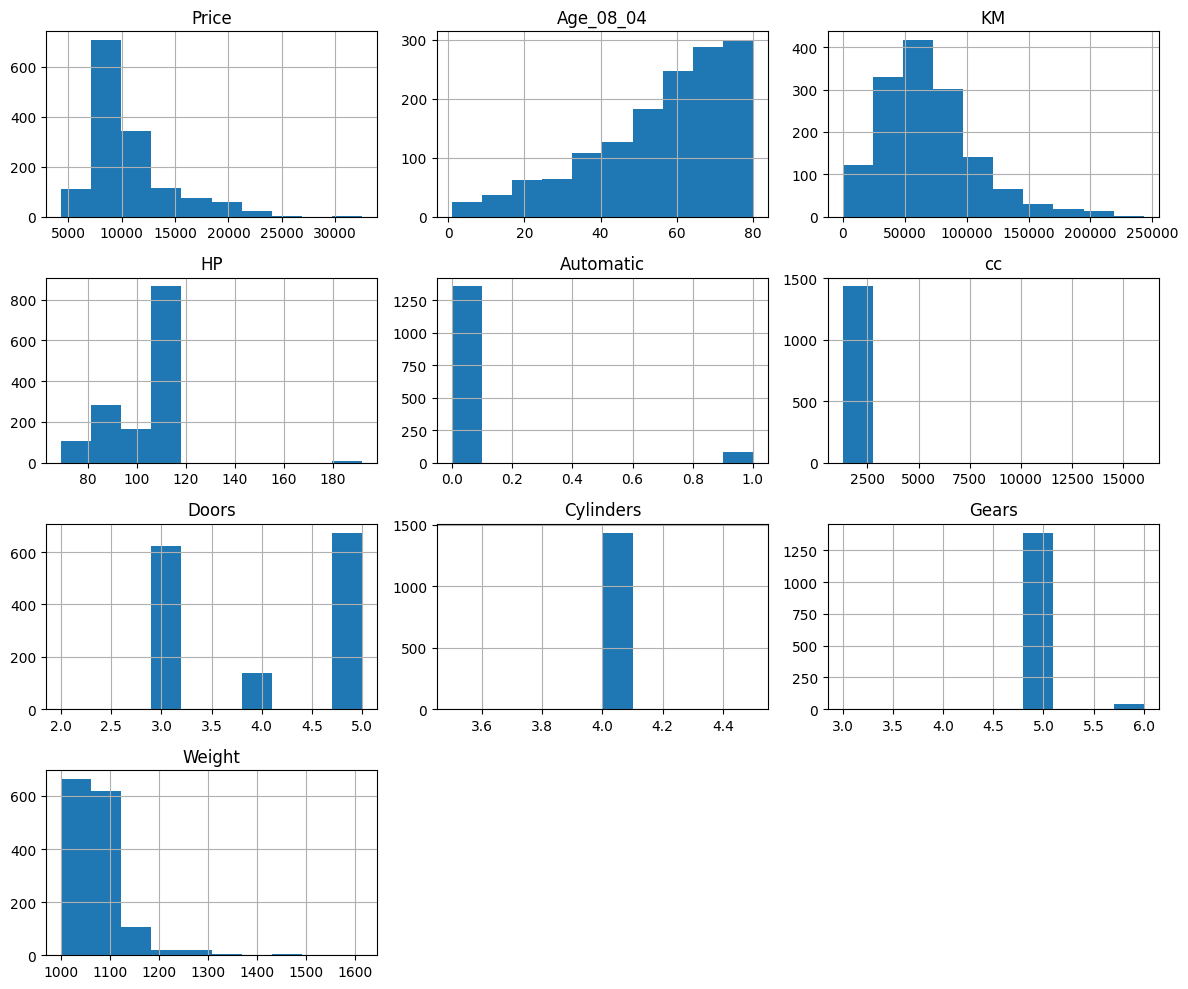

In [7]:
num_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc',
            'Doors', 'Cylinders', 'Gears', 'Weight']
# Plot histograms for numeric columns
df[num_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

1.4 Boxplot of Price vs Fuel_Type

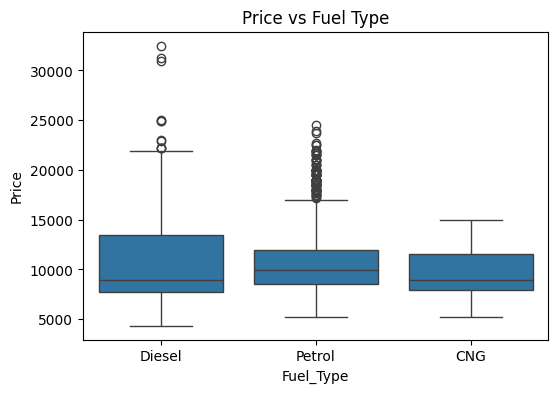

In [8]:
df2 = pd.read_csv("ToyotaCorolla - MLR.csv")
plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type', y='Price', data=df2)
plt.title("Price vs Fuel Type")
plt.show()

1.5 Correlation matrix

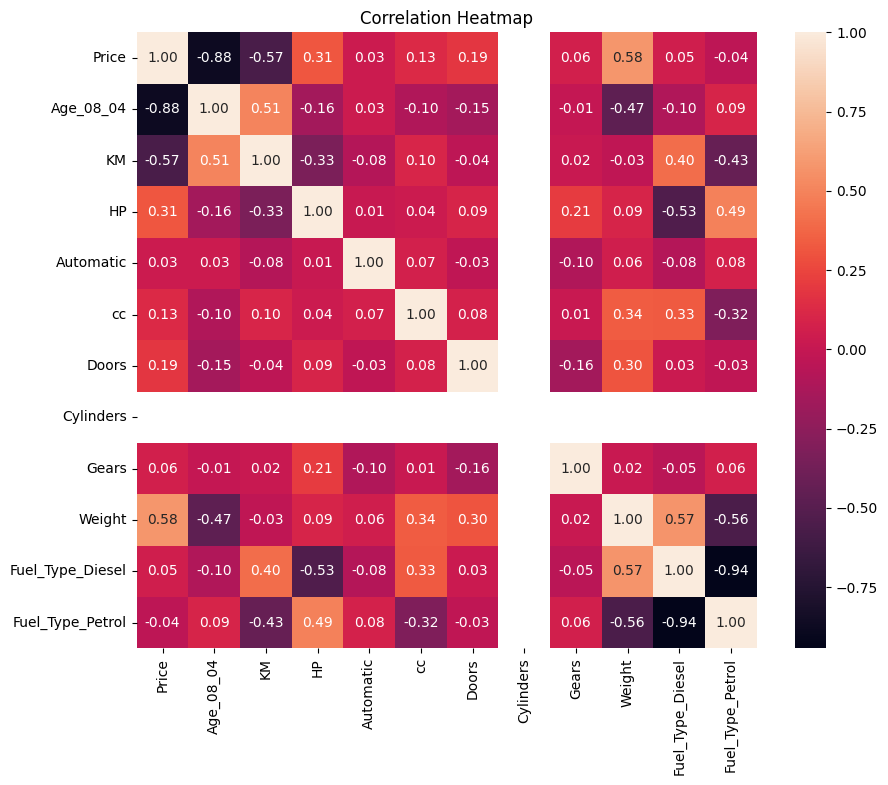

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Task 2: Split the dataset into training and testing sets (e.g., 80% training, 20% testing).


In [10]:
X = df.drop('Price', axis=1)
y = df['Price']
# Train-test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((1148, 11), (288, 11))

Task 3: Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.

In [11]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Print MAE, RMSE and R^2 for train and test for a given model."""
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f"=== {name} ===")
    print(f"Train MAE : {mae_train:.2f}")
    print(f"Test  MAE : {mae_test:.2f}")
    print(f"Train RMSE: {rmse_train:.2f}")
    print(f"Test  RMSE: {rmse_test:.2f}")
    print(f"Train R^2 : {r2_train:.4f}")
    print(f"Test  R^2 : {r2_test:.4f}")
    print("-----------------------------")

Model 1: Linear Regression with all features

In [12]:
# Model 1: all features
linreg1 = LinearRegression()
linreg1.fit(X_train, y_train)
evaluate_model("Model 1: All Features", linreg1, X_train, y_train, X_test, y_test)

=== Model 1: All Features ===
Train MAE : 956.69
Test  MAE : 990.89
Train RMSE: 1303.34
Test  RMSE: 1484.27
Train R^2 : 0.8703
Test  R^2 : 0.8349
-----------------------------


Coefficients of Model 1

In [13]:
coeff_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linreg1.coef_
})
coeff_df1

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.620037e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


Model 2: Linear Regression with a subset of “important” features

In [14]:
base_features = ['Age_08_04', 'KM', 'HP', 'cc', 'Weight', 'Automatic', 'Doors']
fuel_cols = [col for col in X.columns if col.startswith('Fuel_Type_')]
features_model2 = base_features + fuel_cols
X_train_m2 = X_train[features_model2]
X_test_m2 = X_test[features_model2]
# Model 2
linreg2 = LinearRegression()
linreg2.fit(X_train_m2, y_train)
evaluate_model("Model 2: Selected Important Features", linreg2,
               X_train_m2, y_train, X_test_m2, y_test)
# Coefficients
coeff_df2 = pd.DataFrame({
    'Feature': features_model2,
    'Coefficient': linreg2.coef_
})
coeff_df2

=== Model 2: Selected Important Features ===
Train MAE : 959.27
Test  MAE : 992.30
Train RMSE: 1307.44
Test  RMSE: 1491.41
Train R^2 : 0.8694
Test  R^2 : 0.8333
-----------------------------


,Feature,Coefficient
0,Age_08_04,-120.823078
1,KM,-0.015927
2,HP,15.777213
3,cc,-0.030236
4,Weight,26.069186
5,Automatic,93.081993
6,Doors,-84.483547
7,Fuel_Type_Diesel,4.202110
8,Fuel_Type_Petrol,1453.694461


Model 3: Simple model with only Age, KM, HP, Weight

In [15]:
features_model3 = ['Age_08_04', 'KM', 'HP', 'Weight']
X_train_m3 = X_train[features_model3]
X_test_m3 = X_test[features_model3]
linreg3 = LinearRegression()
linreg3.fit(X_train_m3, y_train)
evaluate_model("Model 3: Age + KM + HP + Weight", linreg3,
               X_train_m3, y_train, X_test_m3, y_test)
coeff_df3 = pd.DataFrame({
    'Feature': features_model3,
    'Coefficient': linreg3.coef_
})
coeff_df3

=== Model 3: Age + KM + HP + Weight ===
Train MAE : 993.78
Test  MAE : 1001.20
Train RMSE: 1333.04
Test  RMSE: 1411.85
Train R^2 : 0.8643
Test  R^2 : 0.8506
-----------------------------


,Feature,Coefficient
0,Age_08_04,-120.025405
1,KM,-0.020233
2,HP,29.052170
3,Weight,19.769066


Task 4: Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

From the three models we built, Model 3 (Age + KM + HP + Weight) performs the best on the testing dataset.
It has:

Highest Test R²: 0.8506

Lowest Test RMSE: 1411.85

This means Model 3 explains the highest amount of variation in car prices and gives the most accurate predictions on new data, even though it uses fewer variables.

Model 1 and Model 2 also perform well (Test R² around 0.83), but they use more features and still do not outperform Model 3.

Model 3 is the best model because it has the highest Test R² and the lowest Test RMSE.
It gives better predictions than Model 1 and Model 2 even though it uses fewer variables.
This shows that a simpler model can perform better and generalize well to unseen data.

Task 5: Apply Lasso and Ridge methods on the model.

5.1 Standardize features (using all predictors)

In [16]:
X_train_all = X_train.copy()
X_test_all = X_test.copy()
# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

5.2 Ridge Regression

In [17]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
evaluate_model("Ridge Regression (alpha=1.0)", ridge,
               X_train_scaled, y_train, X_test_scaled, y_test)

=== Ridge Regression (alpha=1.0) ===
Train MAE : 956.70
Test  MAE : 990.86
Train RMSE: 1303.34
Test  RMSE: 1483.56
Train R^2 : 0.8703
Test  R^2 : 0.8350
-----------------------------


5.3 Lasso Regression

In [18]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
evaluate_model("Lasso Regression (alpha=0.1)", lasso,
               X_train_scaled, y_train, X_test_scaled, y_test)
lasso_coeffs = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Coefficient': lasso.coef_
})
lasso_coeffs

=== Lasso Regression (alpha=0.1) ===
Train MAE : 956.69
Test  MAE : 990.90
Train RMSE: 1303.34
Test  RMSE: 1484.16
Train R^2 : 0.8703
Test  R^2 : 0.8349
-----------------------------


,Feature,Coefficient
0,Age_08_04,-2267.270353
1,KM,-611.710485
2,HP,208.460180
3,Automatic,34.335631
4,cc,-14.044285
5,Doors,-57.288237
6,Cylinders,0.000000
7,Gears,109.268038
8,Weight,1316.405210
9,Fuel_Type_Diesel,-21.484319


Interview Questions:


Q1. What is Normalization & Standardization and how is it helpful?

Normalization:

Usually means scaling a feature to a fixed range, like 0 to 1.

Common method: x_norm = (x - min) / (max - min)

Useful when features have very different scales and we are using distance-based or gradient-based methods (e.g., KNN, Neural Networks).

Standardization:

Transforms data to have mean = 0 and standard deviation = 1.

Formula: z = (x - mean) / std

Very common for methods like Linear Regression (with regularization), Logistic Regression, SVM, etc.

How it is helpful (simple):

Makes all features on similar scale.

Helps gradient-based algorithms converge faster.

In Lasso and Ridge, it ensures that regularization treats all features fairly (not dominated by variables with large numeric values).


Q2. What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity means predictors are strongly correlated with each other. This makes coefficients unstable and hard to interpret.

Ways to handle it:

Remove one of the highly correlated variables

Example: if Age_08_04 and KM are very strongly correlated, you can keep only one of them.

Combine variables

Create a new feature like ratio or average if it makes sense from business perspective.

Use Regularization methods

Ridge Regression: shrinks coefficients and handles multicollinearity well.

Lasso Regression: also shrinks and can remove some variables.

Use Principal Component Analysis (PCA)

Transforms original correlated variables into new uncorrelated components (but interpretation becomes harder).

Check VIF (Variance Inflation Factor)

Calculate VIF and drop variables with very high VIF values.